<a href="https://colab.research.google.com/github/JotJaw/data-science-bootcamp/blob/main/02_analiza_danych/02_dane_gieldowe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')

numpy version: 2.0.2
pandas version: 2.2.2


#Załadowanie danych

In [4]:
def fetch_financial_data(company='AMZN'):
  """Pobiera dane dotyczące notowań spółek na giełdzie według symboli
  z seriwsu stooq.pl"""
  import pandas_datareader.data as web
  return web.DataReader(name=company, data_source='stooq')

df = fetch_financial_data()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2026-03-09 to 2021-03-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1254 non-null   float64
 1   High    1254 non-null   float64
 2   Low     1254 non-null   float64
 3   Close   1254 non-null   float64
 4   Volume  1254 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [5]:
df #jako indeks data sesji giełdowej - mogą być przerwy weekendowe;
#cena otwarcia, najwyższa, najniższa w ciągu dnia, oraz cena zamknięcia; Volume - wartość wlumenu, ile papieru obróciło się podczas danej sesji giełdowej

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,210.450,213.820,207.110,213.420,54642926
2026-03-06,214.990,217.320,212.530,213.120,51152716
2026-03-05,215.980,220.470,215.590,218.860,60943447
2026-03-04,210.470,217.540,210.150,216.820,54731101
2026-03-03,203.100,209.178,202.480,208.630,43184918
...,...,...,...,...,...
2021-03-17,153.661,158.652,153.511,156.786,62371680
2021-03-16,155.248,156.445,153.793,154.593,50775280
2021-03-15,153.728,154.112,151.604,154.084,58371840


In [6]:
df.head() #bez prarametru - 5 pierwszych wierszy, z parametrem - tyle, ile chcemy

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,210.45,213.820,207.11,213.42,54642926
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-03,203.10,209.178,202.48,208.63,43184918


In [7]:
df.tail() #5 ostatnich

,Open,High,Low,Close,Volume
Date,,,,,
2021-03-17,153.661,158.652,153.511,156.786,62371680
2021-03-16,155.248,156.445,153.793,154.593,50775280
2021-03-15,153.728,154.112,151.604,154.084,58371840
2021-03-12,153.750,154.949,152.275,154.474,48437760
2021-03-11,155.200,156.589,154.146,155.680,55527820


In [8]:
df.head(3)

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,210.45,213.82,207.11,213.42,54642926
2026-03-06,214.99,217.32,212.53,213.12,51152716
2026-03-05,215.98,220.47,215.59,218.86,60943447


In [9]:
df.tail(1)

,Open,High,Low,Close,Volume
Date,,,,,
2021-03-11,155.2,156.589,154.146,155.68,55527820


In [10]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [11]:
df.columns = [col.lower() for col in df.columns] #zmiana nazw kolumn w df
df.head()

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.11,213.42,54642926
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-03,203.10,209.178,202.48,208.63,43184918


In [12]:
df.describe()

,open,high,low,close,volume
count,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,165.737951,167.693010,163.638199,165.714443,5.681407e+07
std,42.062213,42.222512,41.761580,42.003770,2.703882e+07
min,82.800000,83.480000,81.430000,81.820000,1.142054e+07
25%,131.997500,133.600000,130.443750,131.932500,3.953774e+07
50%,167.860500,169.749000,166.310000,168.631000,5.080720e+07
75%,194.661250,197.245000,192.285000,194.527500,6.636190e+07
max,255.360000,258.600000,252.900000,254.000000,2.726617e+08


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
open,1254.0,1.657380e+02,4.206221e+01,82.80,1.319975e+02,1.678605e+02,1.946612e+02,2.553600e+02
high,1254.0,1.676930e+02,4.222251e+01,83.48,1.336000e+02,1.697490e+02,1.972450e+02,2.586000e+02
low,1254.0,1.636382e+02,4.176158e+01,81.43,1.304438e+02,1.663100e+02,1.922850e+02,2.529000e+02
close,1254.0,1.657144e+02,4.200377e+01,81.82,1.319325e+02,1.686310e+02,1.945275e+02,2.540000e+02
volume,1254.0,5.681407e+07,2.703882e+07,11420543.00,3.953774e+07,5.080720e+07,6.636190e+07,2.726617e+08


#Selekca kolumn

In [15]:
df = df.head(10)
df

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.110,213.42,54642926
2026-03-06,214.99,217.320,212.530,213.12,51152716
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-25,210.46,211.590,208.930,210.64,41346400


In [16]:
df['open']

,open
Date,
2026-03-09,210.45
2026-03-06,214.99
2026-03-05,215.98
2026-03-04,210.47
2026-03-03,203.10
2026-03-02,204.55
2026-02-27,206.83
2026-02-26,210.73
2026-02-25,210.46


In [ ]:
df.open

In [17]:
df[['open']] #przekazane jako lista kolumn - wycięte jako df

,open
Date,
2026-03-09,210.45
2026-03-06,214.99
2026-03-05,215.98
2026-03-04,210.47
2026-03-03,203.10
2026-03-02,204.55
2026-02-27,206.83
2026-02-26,210.73
2026-02-25,210.46


In [18]:
df[['open','close']]

,open,close
Date,,
2026-03-09,210.45,213.42
2026-03-06,214.99,213.12
2026-03-05,215.98,218.86
2026-03-04,210.47,216.82
2026-03-03,203.10,208.63
2026-03-02,204.55,208.39
2026-02-27,206.83,210.00
2026-02-26,210.73,207.92
2026-02-25,210.46,210.64


In [19]:
df.iloc[:,0]

,open
Date,
2026-03-09,210.45
2026-03-06,214.99
2026-03-05,215.98
2026-03-04,210.47
2026-03-03,203.10
2026-03-02,204.55
2026-02-27,206.83
2026-02-26,210.73
2026-02-25,210.46


In [20]:
df.iloc[:,0:3]

,open,high,low
Date,,,
2026-03-09,210.45,213.820,207.110
2026-03-06,214.99,217.320,212.530
2026-03-05,215.98,220.470,215.590
2026-03-04,210.47,217.540,210.150
2026-03-03,203.10,209.178,202.480
2026-03-02,204.55,209.730,203.460
2026-02-27,206.83,210.330,205.200
2026-02-26,210.73,211.050,205.345
2026-02-25,210.46,211.590,208.930


In [21]:
df.iloc[:,3:5]

,close,volume
Date,,
2026-03-09,213.42,54642926
2026-03-06,213.12,51152716
2026-03-05,218.86,60943447
2026-03-04,216.82,54731101
2026-03-03,208.63,43184918
2026-03-02,208.39,46001010
2026-02-27,210.00,57191213
2026-02-26,207.92,47531800
2026-02-25,210.64,41346400


In [23]:
df.iloc[:,-1]

,volume
Date,
2026-03-09,54642926
2026-03-06,51152716
2026-03-05,60943447
2026-03-04,54731101
2026-03-03,43184918
2026-03-02,46001010
2026-02-27,57191213
2026-02-26,47531800
2026-02-25,41346400


In [24]:
df.iloc[:,[-1]]

,volume
Date,
2026-03-09,54642926
2026-03-06,51152716
2026-03-05,60943447
2026-03-04,54731101
2026-03-03,43184918
2026-03-02,46001010
2026-02-27,57191213
2026-02-26,47531800
2026-02-25,41346400


In [25]:
df.iloc[:-3]

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.11,213.42,54642926
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-03,203.10,209.178,202.48,208.63,43184918
2026-03-02,204.55,209.730,203.46,208.39,46001010
2026-02-27,206.83,210.330,205.20,210.00,57191213


#Selekcja wierszy

In [26]:
df

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.110,213.42,54642926
2026-03-06,214.99,217.320,212.530,213.12,51152716
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-25,210.46,211.590,208.930,210.64,41346400


In [31]:
df.iloc[0]

,2026-03-09
open,210.45
high,213.82
low,207.11
close,213.42
volume,54642926.00


In [34]:
df.iloc[:3]

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.82,207.11,213.42,54642926
2026-03-06,214.99,217.32,212.53,213.12,51152716
2026-03-05,215.98,220.47,215.59,218.86,60943447


In [41]:
df.loc[['2026-03-03']]

,open,high,low,close,volume
Date,,,,,
2026-03-03,203.1,209.178,202.48,208.63,43184918


In [42]:
df.loc['2026-03-03']

,2026-03-03
open,2.031000e+02
high,2.091780e+02
low,2.024800e+02
close,2.086300e+02
volume,4.318492e+07


In [43]:
df.loc[['2026-03-03','2026-03-04']]


,open,high,low,close,volume
Date,,,,,
2026-03-03,203.10,209.178,202.48,208.63,43184918
2026-03-04,210.47,217.540,210.15,216.82,54731101


In [46]:
df

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.110,213.42,54642926
2026-03-06,214.99,217.320,212.530,213.12,51152716
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-25,210.46,211.590,208.930,210.64,41346400


In [52]:
df.sort_index(inplace=True)

In [57]:
df

,open,high,low,close,volume
Date,,,,,
2026-02-24,205.47,210.360,203.250,208.56,41137200
2026-02-25,210.46,211.590,208.930,210.64,41346400
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-06,214.99,217.320,212.530,213.12,51152716


In [56]:
df.loc['2026-03-02':'2026-03-10']

,open,high,low,close,volume
Date,,,,,
2026-03-02,204.55,209.730,203.46,208.39,46001010
2026-03-03,203.10,209.178,202.48,208.63,43184918
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-09,210.45,213.820,207.11,213.42,54642926


#Obliczanie nowych kolumn

In [60]:
df = fetch_financial_data('UBER')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2026-03-09 to 2021-03-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1254 non-null   float64
 1   High    1254 non-null   float64
 2   Low     1254 non-null   float64
 3   Close   1254 non-null   float64
 4   Volume  1254 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [61]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,74.17,74.540,71.940,73.84,21208861
2026-03-06,74.73,75.570,74.190,75.13,14771234
2026-03-05,76.59,78.250,75.135,75.44,17893964
2026-03-04,75.87,77.040,75.013,76.65,19818516
2026-03-03,74.50,77.305,74.020,76.36,21892515


In [62]:
df.describe() #czy są braki

,Open,High,Low,Close,Volume
count,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,55.850865,56.774363,54.901963,55.842249,2.343554e+07
std,21.881676,22.075822,21.619597,21.854289,1.608937e+07
min,20.370000,21.125500,19.895000,20.460000,4.310663e+06
25%,36.637500,37.585000,35.590000,36.710000,1.540215e+07
50%,50.940000,51.630000,50.230000,50.810000,1.983204e+07
75%,73.683750,74.811250,72.535000,73.822500,2.730426e+07
max,100.130000,101.990000,98.585000,100.100000,3.642612e+08


In [64]:
df.head(3)

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,74.17,74.54,71.940,73.84,21208861
2026-03-06,74.73,75.57,74.190,75.13,14771234
2026-03-05,76.59,78.25,75.135,75.44,17893964


In [66]:
df['Average'] = (df.Open + df.Close) / 2.0
df.head()

,Open,High,Low,Close,Volume,Average
Date,,,,,,
2026-03-09,74.17,74.540,71.940,73.84,21208861,74.005
2026-03-06,74.73,75.570,74.190,75.13,14771234,74.930
2026-03-05,76.59,78.250,75.135,75.44,17893964,76.015
2026-03-04,75.87,77.040,75.013,76.65,19818516,76.260
2026-03-03,74.50,77.305,74.020,76.36,21892515,75.430


In [68]:
df = df.sort_index()
df.head()

,Open,High,Low,Close,Volume,Average
Date,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715


In [71]:
df[['Close']].shift(1)

,Close
Date,
2021-03-11,NaN
2021-03-12,58.95
2021-03-15,60.35
2021-03-16,60.19
2021-03-17,58.85
...,...
2026-03-03,75.95
2026-03-04,76.36
2026-03-05,76.65


In [74]:
df['Close_shift'] = df[['Close']].shift(1)
df.head()

,Open,High,Low,Close,Volume,Average,Close_shift
Date,,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875,NaN
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660,58.95
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270,60.35
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420,60.19
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715,58.85


In [75]:
df.Close / df.Close_shift - 1 #dzienna zamiana wyrażona w procentach

,0
Date,
2021-03-11,NaN
2021-03-12,0.023749
2021-03-15,-0.002651
2021-03-16,-0.022263
2021-03-17,-0.042311
...,...
2026-03-03,0.005398
2026-03-04,0.003798
2026-03-05,-0.015786


In [ ]:
df['Daily_Change'] = df.Close / df.Close_shift - 1
df.head()

In [82]:
df['Daily Change'] = df.Close / df.Close_shift - 1
df.head()

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change,Daily Change
Date,,,,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875,NaN,NaN,NaN
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660,58.95,0.023749,0.023749
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270,60.35,-0.002651,-0.002651
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420,60.19,-0.022263,-0.022263
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715,58.85,-0.042311,-0.042311


In [83]:
del df['Daily Change']
df.head()

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875,NaN,NaN
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660,58.95,0.023749
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270,60.35,-0.002651
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420,60.19,-0.022263
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715,58.85,-0.042311


In [84]:
df.Daily_Change.min()

-0.11584196394322976

In [85]:
df.Daily_Change.max()

0.18902439024390238

<Axes: >

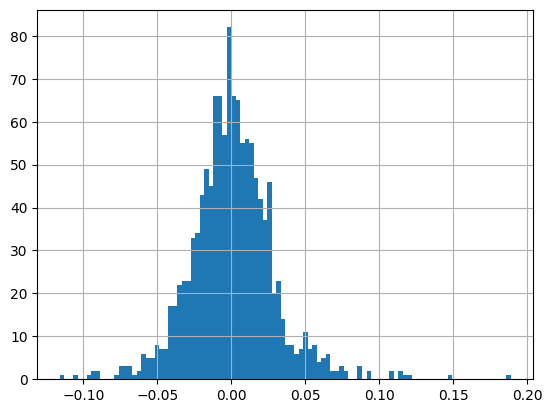

In [86]:
  df.Daily_Change.hist(bins=100) #histogram stopy zwrotu

<Axes: >

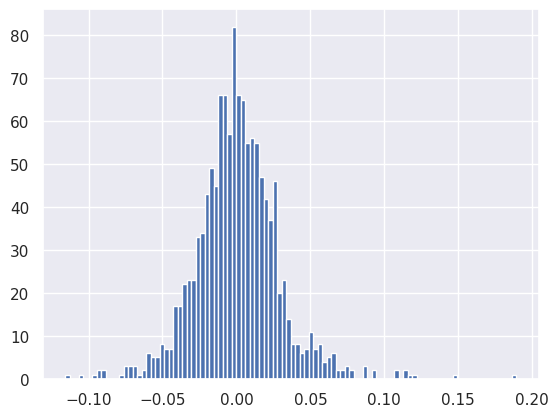

In [88]:
import seaborn as sns
sns.set()

df.Daily_Change.hist(bins=100)
#

<Axes: xlabel='Date'>

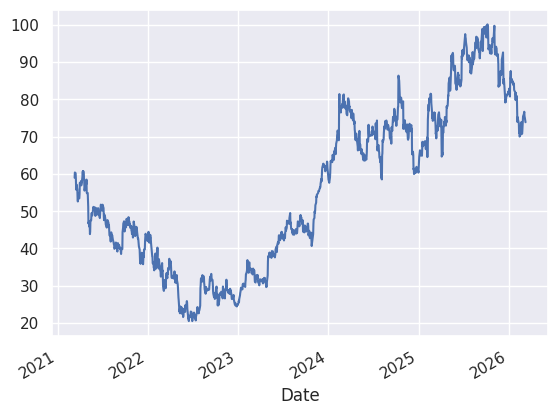

In [89]:
df.Close.plot() #notowania spółki

polecany kurs dla bardziej głębokich wyliczeń, typu średnia ruchoma, pęk średniej - Wprowadzenie do Data Science w języku Python Pandas